# Single-frequency forecasting quick start

This small, deterministic example forecasts two components and their total while enforcing the accounting identity

$$\mathrm{component\_a} + \mathrm{component\_b} = \mathrm{total}.$$

Install the package with `pip install macroframe-forecast` before running the notebook.

In [1]:
import numpy as np
import pandas as pd
from sktime.forecasting.naive import NaiveForecaster

from macroframe_forecast import MFF

Create reproducible annual data, then mark the final four rows as unknown. `MFF` treats every missing value as a value to forecast. We retain the final total as a known endpoint (an "island") so reconciliation adjusts the component forecasts to meet it.

In [2]:
rng = np.random.default_rng(42)
years = pd.RangeIndex(1990, 2022, name="year")
trend = np.arange(len(years))

observed = pd.DataFrame(
    {
        "component_a": 100 + 1.5 * trend + rng.normal(0, 0.5, len(years)),
        "component_b": 60 + 0.8 * trend + rng.normal(0, 0.5, len(years)),
    },
    index=years,
)
observed["total"] = observed["component_a"] + observed["component_b"]

forecast_horizon = 4
data = observed.copy()
data.iloc[-forecast_horizon:] = np.nan
data.loc[data.index[-1], "total"] = observed.loc[observed.index[-1], "total"]
data.tail(6)

,component_a,component_b,total
year,,,
2016,139.266155,80.367084,219.633239
2017,140.682722,82.084139,222.766861
2018,NaN,NaN,NaN
2019,NaN,NaN,NaN
2020,NaN,NaN,NaN
2021,NaN,NaN,231.389904


Use `?` as the time wildcard in the identity. Setting `parallelize=False` keeps this small example simple, while a naive drift forecaster makes it quick to run.

In [3]:
model = MFF(
    data,
    forecaster=NaiveForecaster(strategy="drift"),
    equality_constraints=["component_a_? + component_b_? - total_?"],
    parallelize=False,
    n_forecast_error=2,
)
forecast = model.fit()
forecast.tail(6)

Forecast 12 cells: 0.109 seconds
Fill 24 in-sample cells: 0.209 seconds


,component_a,component_b,total
year,,,
2016,139.266155,80.367084,219.633239
2017,140.682722,82.084139,222.766861
2018,142.136919,82.889818,225.026737
2019,143.621460,83.660285,227.281745
2020,145.087541,84.653805,229.741347
2021,146.353246,85.036658,231.389904


`model.df1` contains the first-stage forecasts. The returned dataframe contains the reconciled forecasts, which meet the known endpoint and satisfy the identity.

In [4]:
comparison = pd.concat(
    {"first_stage": model.df1, "reconciled": forecast},
    axis=1,
)
display(comparison.tail(forecast_horizon))

identity_error = forecast["component_a"] + forecast["component_b"] - forecast["total"]
assert forecast.iloc[-forecast_horizon:].notna().all().all()
assert np.allclose(identity_error, 0)
identity_error.tail(forecast_horizon)

first_stage                          reconciled                        
     component_a component_b       total component_a component_b       total
year                                                                        
2018  142.183847   82.911556  225.095403  142.136919   82.889818  225.026737
2019  143.684971   83.738973  227.423944  143.621460   83.660285  227.281745
2020  145.186096   84.566390  229.752486  145.087541   84.653805  229.741347
2021  146.687220   85.393807  232.081028  146.353246   85.036658  231.389904

year
2018    5.684342e-14
2019    0.000000e+00
2020   -2.842171e-14
2021    0.000000e+00
dtype: float64

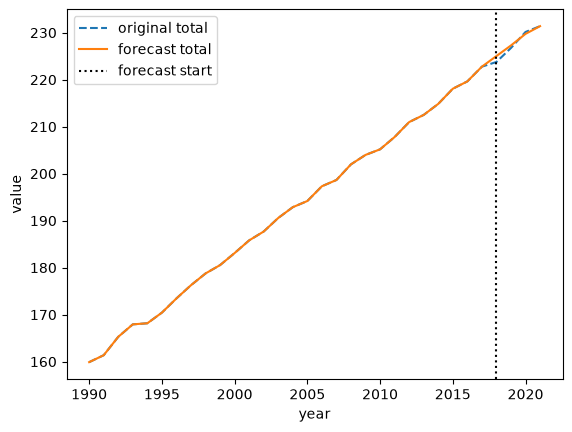

In [5]:
ax = observed["total"].plot(label="original total", linestyle="--")
forecast["total"].plot(ax=ax, label="forecast total")
ax.axvline(data.index[-forecast_horizon], color="black", linestyle=":", label="forecast start")
ax.set_ylabel("value")
ax.legend();